# Task 1

### Imports

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Transition matrix

In [11]:
# Transition matrix
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.0000, 0.986,  0.0050, 0.004, 0.005],
    [0.0000, 0.000,  0.9920, 0.003, 0.005],
    [0.0000, 0.000,  0.0000, 0.991, 0.009],
    [0.0000, 0.000,  0.0000, 0.000, 1.000]
])

# Check that rows sum to 1
print(P.sum(axis=1))

[1. 1. 1. 1. 1.]


### Sample probabilties for transition and one woman lifetime simulation

In [12]:
def sample_next_state(probabilities, rng):
    """
    Input:
        probabilities: array of probabilities for the next state (rows of P)
        rng: random number generator
    Output:         next state (1 to 5)

    Direct method for sampling from a discrete distribution.
    States are numbered 1, ..., 5.
    """
    u = rng.random()
    cumulative = np.cumsum(probabilities) # cumulative distribution function
    return np.searchsorted(cumulative, u) + 1 # find the first index where cumulative exceeds u, +1 for 1-based state numbering


def simulate_one_woman(P, rng, check_month=60):
    """
    Simulate one woman from state 1 until death.
    Outputs:
        lifetime: number of months until death
        recurrence: whether any recurrence (local or distant) ever occurred
        local_recurrence: whether local recurrence ever occurred
        state_at_check: state at the validation month
    """
    state = 1
    lifetime = 0
    recurrence = False         # any cancer recurrence: local or distant
    local_recurrence = False   # local recurrence specifically
    state_at_check = None

    while state != 5:
        # Save state at validation month
        if lifetime == check_month:
            state_at_check = state

        # Move one month forward
        state = sample_next_state(P[state - 1], rng)
        lifetime += 1

        if state in [2, 3, 4]:
            recurrence = True

        if state in [2, 4]:
            local_recurrence = True

    # If death happened before the validation month, state remains 5
    if state_at_check is None:
        state_at_check = 5

    return lifetime,recurrence, local_recurrence, state_at_check

### Simulation settings

In [13]:
n = 1000 # number of women
seed = 1
check_month = 60   # for validation, e.g. after 5 years

rng = np.random.default_rng(seed) # we use system random number generator

lifetimes = np.zeros(n, dtype=int) # to store lifetimes of all women
recurrence = np.zeros(n, dtype=bool) # to store whether any recurrence occurred for each woman
local_recurrence = np.zeros(n, dtype=bool) # to store whether local recurrence occurred for each woman
states_at_check = np.zeros(n, dtype=int) # to store state at validation month for each woman

for i in range(n): # simulate one woman at a time and store results in the arrays
    lifetimes[i], recurrence[i], local_recurrence[i], states_at_check[i] = simulate_one_woman(
        P, rng, check_month=check_month
    )

### Summary of results

In [14]:
lifetime_summary = pd.DataFrame({
    "Mean lifetime (months)": [np.mean(lifetimes)],
    "Median lifetime (months)": [np.median(lifetimes)],
    "Std. dev. (months)": [np.std(lifetimes, ddof=1)],
    "Min": [np.min(lifetimes)],
    "25% quantile": [np.quantile(lifetimes, 0.25)],
    "75% quantile": [np.quantile(lifetimes, 0.75)],
    "Max": [np.max(lifetimes)]
})

lifetime_summary

,Mean lifetime (months),Median lifetime (months),Std. dev. (months),Min,25% quantile,75% quantile,Max
0,259.131,208.0,192.890224,1,117.75,354.0,1173


### Plot of simulation

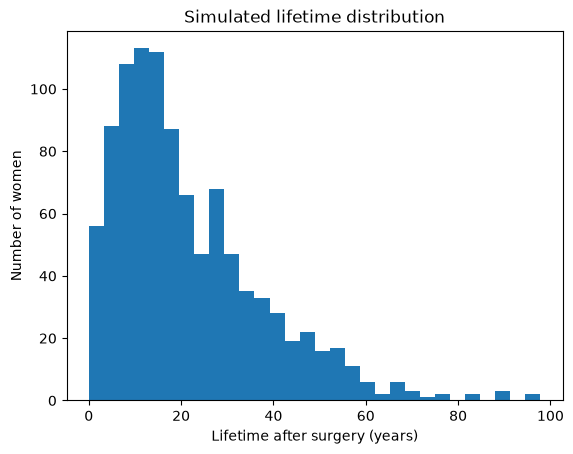

In [15]:
plt.hist(lifetimes / 12, bins=30)
plt.xlabel("Lifetime after surgery (years)")
plt.ylabel("Number of women")
plt.title("Simulated lifetime distribution")
plt.show()

In [16]:
prop_any_recurrence = np.mean(recurrence)
prop_local_recurrence = np.mean(local_recurrence)
prop_local_given_recurrence = np.sum(local_recurrence) / np.sum(recurrence)

print("Proportion with any recurrence:", prop_any_recurrence)
print("Proportion with local recurrence:", prop_local_recurrence)
print("Proportion local among those with recurrence:", prop_local_given_recurrence)

Proportion with any recurrence: 0.889
Proportion with local recurrence: 0.705
Proportion local among those with recurrence: 0.7930258717660292


### Validation

In [17]:
# Analytical distribution at check_month
p0 = np.array([1, 0, 0, 0, 0])
analytical = p0 @ np.linalg.matrix_power(P, check_month)

# Simulated distribution at check_month
counts = np.bincount(states_at_check, minlength=6)[1:]
simulated = counts / n

validation_table = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Simulated": simulated,
    "Analytical": analytical,
    "Difference": simulated - analytical
})

validation_table

,State,Simulated,Analytical,Difference
0,1,0.597,0.599188,-0.002188
1,2,0.162,0.154575,0.007425
2,3,0.108,0.116549,-0.008549
3,4,0.031,0.028794,0.002206
4,5,0.102,0.100895,0.001105


# Task 2

### More imports

In [18]:
from scipy.stats import chisquare

In [19]:
def simulate_state_at_t(P, t, rng): # simulate state at month t starting from state 1
    state = 1
    
    for _ in range(t):
        state = sample_next_state(P[state - 1], rng)
    
    return state

In [20]:
n = 1000
t = 120
rng = np.random.default_rng(1)

states_120 = np.zeros(n, dtype=int)

for i in range(n):
    states_120[i] = simulate_state_at_t(P, t, rng)

### Simulated distribution

In [21]:
observed_counts = np.bincount(states_120, minlength=6)[1:]
observed_distribution = observed_counts / n

observed_counts, observed_distribution

(array([352, 179, 161,  64, 244]), array([0.352, 0.179, 0.161, 0.064, 0.244]))

### Analytical distribution

In [24]:
p0 = np.array([1, 0, 0, 0, 0])

analytical_distribution = p0 @ np.linalg.matrix_power(P, t)
expected_counts = n * analytical_distribution

expected_counts, analytical_distribution

(array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
        248.18930075]),
 array([0.35902627, 0.15895604, 0.1660869 , 0.06774149, 0.2481893 ]))

### Comparrison

In [25]:
comparison = pd.DataFrame({
    "State": [1, 2, 3, 4, 5],
    "Observed count": observed_counts,
    "Observed proportion": observed_distribution,
    "Expected proportion": analytical_distribution,
    "Expected count": expected_counts
})

comparison

,State,Observed count,Observed proportion,Expected proportion,Expected count
0,1,352,0.352,0.359026,359.026268
1,2,179,0.179,0.158956,158.956040
2,3,161,0.161,0.166087,166.086897
3,4,64,0.064,0.067741,67.741494
4,5,244,0.244,0.248189,248.189301


### Test

In [26]:
chi2_stat, p_value = chisquare(
    f_obs=observed_counts,
    f_exp=expected_counts
)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

Chi-square statistic: 3.0981640968332864
p-value: 0.5415343741426009


The null hypothesis is that the simulated states at t = 120 follow the analytical
distribution p_120 = p_0 P^120. Since the p-value is not small, we do not reject
the null hypothesis. Therefore, the simulated distribution is consistent with the
analytical Markov chain distribution.

# Task 3

In [ ]:
# Task 3: Phase-type distribution of lifetimes

Ps = P[:4, :4]      # transient-state transition matrix, states 1-4. Matrix of probabilities of moving between transient states (not including death)
ps = P[:4, 4]       # probabilities of dying from states 1-4

pi = np.array([1, 0, 0, 0])   # all women start in state 1
one = np.ones(4)

# Theoretical mean lifetime
theoretical_mean = pi @ np.linalg.inv(np.eye(4) - Ps) @ one

sample_mean = np.mean(lifetimes)

print("Sample mean lifetime:", sample_mean)
print("Theoretical mean lifetime:", theoretical_mean)
print("Difference:", sample_mean - theoretical_mean)

Sample mean lifetime: 259.131
Theoretical mean lifetime: 262.3716153127931
Difference: -3.2406153127931248
